## ATSEviz: Visualizing Alternative Splicing Events
This notebook demonstrates how to use the ATSEviz module from LeafletFA-utils to visualize alternative splicing events.

In [12]:
# Import necessary libraries
import pandas as pd
import os
import sys
import pandas as pd
import numpy as np
from typing import List, Set

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

Imports successful!


In [13]:
db_file = "/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250401_150841/annotation.db"
db = gffutils.FeatureDB(db_file, keep_order=True)

In [61]:
# Visualize random ATSEs
p=pd.read_csv("/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250510_134235/atse_events_20250510-134928.tsv.gz", sep="\t")
atse_event = p.sample(1)["event_id"].values[0]
print(f"The atse event is: {atse_event}")

atse_event = "ENSMUSG00000018819.10_atse_1"

# Create a copy of the subset to avoid SettingWithCopyWarning
juncs = p[p["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)
splice_junctions

The atse event is: ENSMUSG00000026222.16_atse_1


[{'chrom': 'chr7',
  'start': 142488515,
  'end': 142488847,
  'name': 'junction_158',
  'strand': '+',
  'usage_ratio': 0.5978966211680465},
 {'chrom': 'chr7',
  'start': 142488515,
  'end': 142488865,
  'name': 'junction_159',
  'strand': '+',
  'usage_ratio': 0.40210337883195346}]

In [62]:
p[p["gene_id"] == "ENSMUSG00000018819.10"]

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,chromosome,strand,atse_start,atse_end,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
157,ENSMUSG00000018819.10_atse_1,ENSMUSG00000018819.10,Lsp1,protein_coding,2,alternative_3_prime,chr7,+,142488515,142488865,...,1.0,0.5979,1.0,4469,2672,GT-AG,GT,AG,0.0,1.0
158,ENSMUSG00000018819.10_atse_1,ENSMUSG00000018819.10,Lsp1,protein_coding,2,alternative_3_prime,chr7,+,142488515,142488865,...,1.0,0.4021,1.0,4469,1797,GT-AG,GT,AG,0.0,1.0
159,ENSMUSG00000018819.10_atse_2,ENSMUSG00000018819.10,Lsp1,protein_coding,2,alternative_3_prime,chr7,+,142490665,142494240,...,1.0,0.0907,1.0,4256,386,GT-AG,GT,AG,0.0,1.0
160,ENSMUSG00000018819.10_atse_2,ENSMUSG00000018819.10,Lsp1,protein_coding,2,alternative_3_prime,chr7,+,142490665,142494240,...,1.0,0.9093,1.0,4256,3870,GT-AG,GT,AG,0.0,1.0


Found 7 unique transcripts
                      transcript_name transcript_type          transcript_id
ENSMUST00000018963.10        Lsp1-201  protein_coding  ENSMUST00000018963.10
ENSMUST00000038946.8         Lsp1-202  protein_coding   ENSMUST00000038946.8
ENSMUST00000105966.1         Lsp1-203  protein_coding   ENSMUST00000105966.1
ENSMUST00000105967.7         Lsp1-204  protein_coding   ENSMUST00000105967.7
ENSMUST00000105968.7         Lsp1-205  protein_coding   ENSMUST00000105968.7
ENSMUST00000140626.7         Lsp1-209  protein_coding   ENSMUST00000140626.7
ENSMUST00000149521.7         Lsp1-211  protein_coding   ENSMUST00000149521.7


Plot saved to test.pdf!


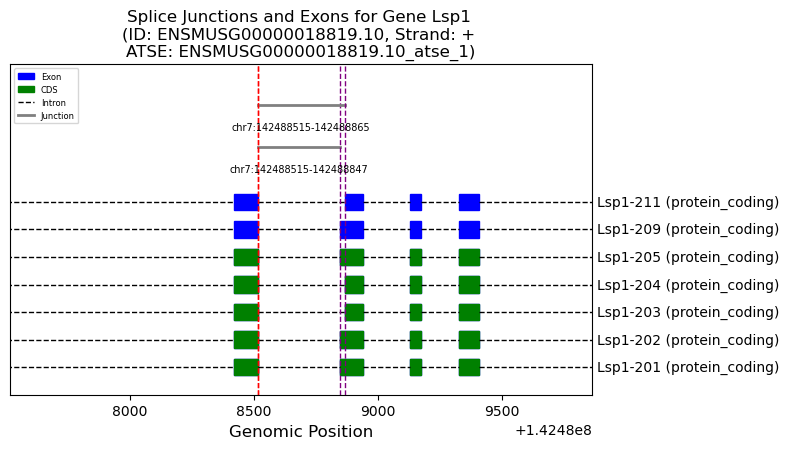

In [63]:
# Example usage:
unique_transcripts = extract_unique_transcripts(juncs)
print(f"Found {len(unique_transcripts)} unique transcripts")

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=8, trans_height=0.5, show_usage=False, show_junc_lines=True, filename="test.pdf")

# TO-DO:
# - Return plot as a plot object that users can add additional things to... matplotlib object? ax... concatenate... 
# - Feed in OG Leafcutter Intron Clusters... via intron cluster table... 
# - Feed in the Junction by Sample Table as input to junction annoation... BED file with extra columns... 
# - Similar to isoform plots, implement the intron scaling thing
# - VIsulize multiple ATSEs per gene wuld be nice 
# - Test on BigBrain bulk RNA-seq files 
# - Test on EasySci junctions 
# - sQTLs or other SNPs would be nice to visualize... 

In [20]:
juncs.iloc[0]["perfect_match_3_prime"]

'ENSMUST00000172912.7'

In [21]:
juncs.iloc[1]["perfect_match_3_prime"]

'ENSMUST00000025181.16,ENSMUST00000087189.6'